# Unzip dataset

In [1]:
!unzip '/content/Mango Leaf Disease Identification Dataset (MLDID).zip'

Archive:  /content/Mango Leaf Disease Identification Dataset (MLDID).zip
   creating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_203940.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_203946.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_203952.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_204000.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_204008.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_204013.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_204022.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_204027.jpg  
  inflating: Mango Leaf Disease Identificat

In [2]:
import os
import shutil
import random

import numpy as np
from skimage import io
from PIL import Image
from keras.preprocessing import image

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage import io
import numpy as np
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
# Import Data Science Libraries
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import itertools
import random

# Import visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

# System libraries
from pathlib import Path
import os.path
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
import skimage
from skimage.transform import resize
# label binarizer
from sklearn.preprocessing import LabelBinarizer
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from ast import main
# Define your dataset directories and the directories where you want to create the splits:

dataset_dir = "/content/Mango Leaf Disease Identification Dataset (MLDID)"  # Replace with the path to your dataset
main_dir = "train_set"
test_dir = "test_set"

# Create the train, test, and validation directories if they don't exist
os.makedirs(main_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [4]:
# Set the split ratio (for main 80% , for test 20%)

main_ratio = 0.80
test_ratio = 0.20

In [5]:
# iterate throught the folders containing our two type of data and splite them into main and test

for class_folder in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_folder)

    if os.path.isdir(class_path):
        file_list = os.listdir(class_path)
        random.shuffle(file_list)

        main_split = int(len(file_list) * main_ratio)
        test_split = int(len(file_list) * (main_ratio + test_ratio))

        main_files = file_list[:main_split]
        test_files = file_list[main_split:test_split]


        for file_name in main_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(main_dir, class_folder, file_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)

        for file_name in test_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(test_dir, class_folder, file_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)



In [6]:
# data
train_dir = '/content/train_set'
test_dir = '/content/test_set'
# Define constants
batch_size = 32
image_size = (224, 224)

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use the training split
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use the validation split
)

Found 1920 images belonging to 5 classes.
Found 479 images belonging to 5 classes.


In [9]:

test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

Found 601 images belonging to 5 classes.


# mobilenetv2

In [ ]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(5, activation='softmax'))

# Compile the model
optimizer_a = Adam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer_a,
              metrics=['accuracy'])

# Train the model
history_m1_a = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 27s 220ms/step - accuracy: 0.7073 - loss: 6.6227 - val_accuracy: 0.8550 - val_loss: 0.5766
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.9176 - loss: 0.4005 - val_accuracy: 0.8651 - val_loss: 0.5272
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.9254 - loss: 0.3157 - val_accuracy: 0.8988 - val_loss: 0.4857
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.9512 - loss: 0.1800 - val_accuracy: 0.9005 - val_loss: 0.3771
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.9550 - loss: 0.1377 - val_accuracy: 0.8617 - val_loss: 0.5170
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - accuracy: 0.9562 - loss: 0.1649 - val_accuracy: 0.9022 - val_loss: 0.5264
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 182ms/step - accuracy: 0.9621 - loss: 0.1601 - val_accuracy: 0.8971 - val_loss: 0.4876
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.9654 - loss: 0.1236 - val_accuracy: 

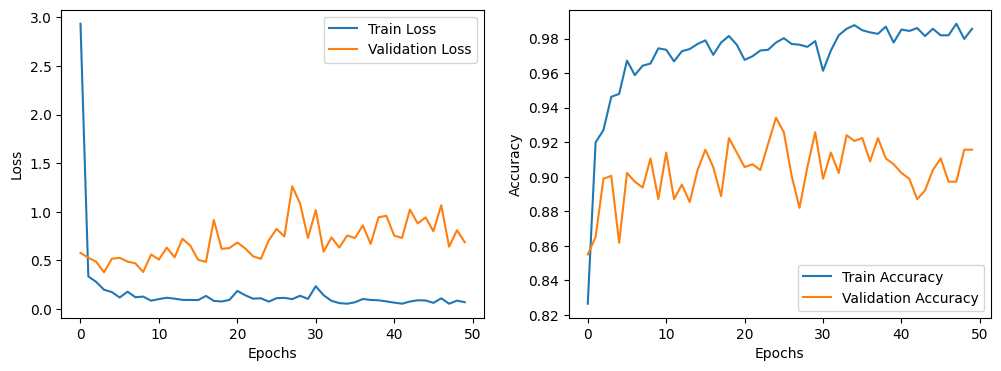

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1_a.history['loss'], label='Train Loss')
plt.plot(history_m1_a.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1_a.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1_a.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       296
           1       0.99      0.98      0.98       297
           2       0.99      1.00      1.00       308
           3       0.97      0.98      0.98       276
           4       0.99      1.00      0.99       290

    accuracy                           0.98      1467
   macro avg       0.98      0.98      0.98      1467
weighted avg       0.98      0.98      0.98      1467



In [ ]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.983640081799591


# NASNetMobile

In [ ]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_NASNetMobile = NASNetMobile(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_NASNetMobile.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_NASNetMobile)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(5, activation='softmax'))

# Compile the model
optimizer_s = Adam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer_s,
              metrics=['accuracy'])

# Train the model
history_m1_s = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 70s 497ms/step - accuracy: 0.5888 - loss: 5.3797 - val_accuracy: 0.8449 - val_loss: 0.5044
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 42s 124ms/step - accuracy: 0.8371 - loss: 0.4477 - val_accuracy: 0.8617 - val_loss: 0.4525
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.8821 - loss: 0.3605 - val_accuracy: 0.8752 - val_loss: 0.4294
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.8840 - loss: 0.3125 - val_accuracy: 0.8600 - val_loss: 0.4889
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - accuracy: 0.9036 - loss: 0.2718 - val_accuracy: 0.8938 - val_loss: 0.3244
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.9213 - loss: 0.2202 - val_accuracy: 0.8583 - val_loss: 0.4526
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.9108 - loss: 0.2513 - val_accuracy: 0.8685 - val_loss: 0.4952
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/ste

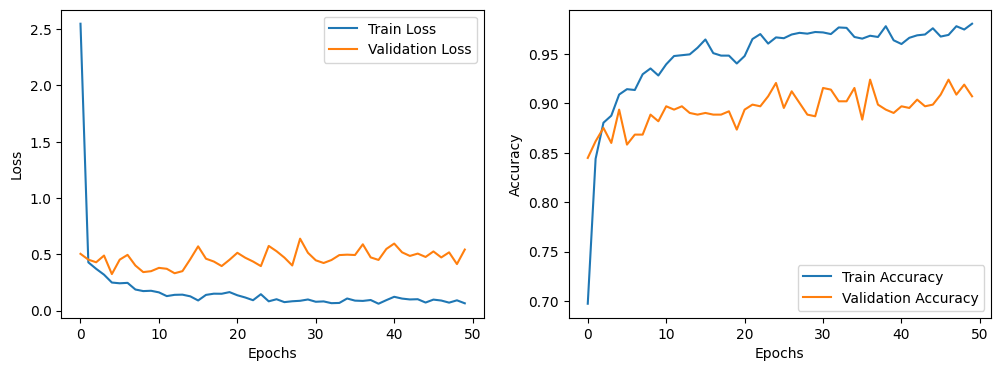

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1_s.history['loss'], label='Train Loss')
plt.plot(history_m1_s.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1_s.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1_s.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 413ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       296
           1       0.96      0.99      0.98       297
           2       0.99      0.99      0.99       308
           3       0.98      0.96      0.97       276
           4       0.99      1.00      1.00       290

    accuracy                           0.98      1467
   macro avg       0.98      0.98      0.98      1467
weighted avg       0.98      0.98      0.98      1467

Accuracy: 0.9775051124744376


# InceptionV3

In [ ]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import RMSprop
import matplotlib.pyplot as plt

# Load pre-trained InceptionV3 model
model_InceptionV3 = InceptionV3(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_InceptionV3.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_InceptionV3)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(5, activation='softmax'))

# Compile the model
optimizer_rs = Adam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer_rs,
              metrics=['accuracy'])

# Train the model
history_m1_rs = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 42s 325ms/step - accuracy: 0.5271 - loss: 12.1117 - val_accuracy: 0.8027 - val_loss: 0.4802
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.7669 - loss: 0.5720 - val_accuracy: 0.8415 - val_loss: 0.4114
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.8475 - loss: 0.3888 - val_accuracy: 0.8702 - val_loss: 0.4101
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.8581 - loss: 0.3866 - val_accuracy: 0.8617 - val_loss: 0.3691
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.8641 - loss: 0.3306 - val_accuracy: 0.8398 - val_loss: 0.4250
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.8843 - loss: 0.3220 - val_accuracy: 0.8820 - val_loss: 0.3579
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.9012 - loss: 0.2570 - val_accuracy: 0.8836 - val_loss: 0.3812
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/st

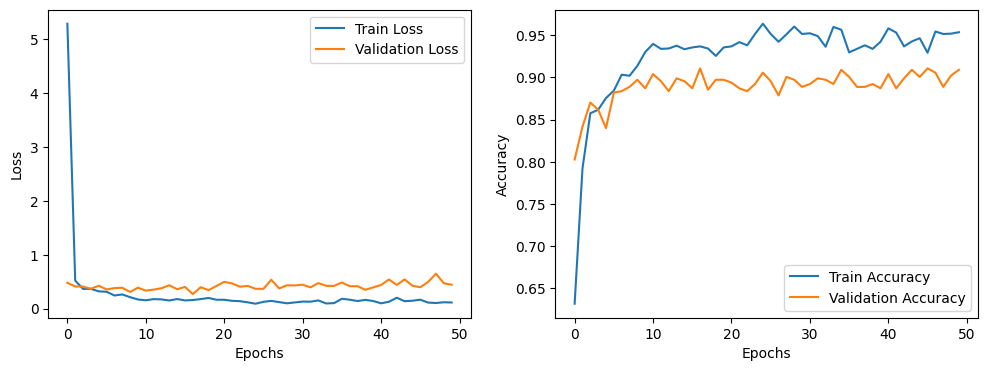

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1_rs.history['loss'], label='Train Loss')
plt.plot(history_m1_rs.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1_rs.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1_rs.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 279ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       296
           1       0.98      0.98      0.98       297
           2       0.99      0.98      0.99       308
           3       0.98      0.95      0.97       276
           4       0.99      1.00      1.00       290

    accuracy                           0.98      1467
   macro avg       0.98      0.98      0.98      1467
weighted avg       0.98      0.98      0.98      1467

Accuracy: 0.9768234492160872


# DenseNet201

In [ ]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Nadam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_DenseNet201 = DenseNet201(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_DenseNet201.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_DenseNet201)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(5, activation='softmax'))

# Compile the model
optimizer_na = Adam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer_na,
              metrics=['accuracy'])

# Train the model
history_na = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 101s 758ms/step - accuracy: 0.6743 - loss: 7.6252 - val_accuracy: 0.9106 - val_loss: 0.3198
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.9332 - loss: 0.2231 - val_accuracy: 0.9275 - val_loss: 0.2555
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step - accuracy: 0.9691 - loss: 0.1149 - val_accuracy: 0.9292 - val_loss: 0.2486
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 208ms/step - accuracy: 0.9646 - loss: 0.0897 - val_accuracy: 0.9191 - val_loss: 0.2937
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.9689 - loss: 0.0990 - val_accuracy: 0.9140 - val_loss: 0.3335
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.9548 - loss: 0.1278 - val_accuracy: 0.9157 - val_loss: 0.3032
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.9562 - loss: 0.1411 - val_accuracy: 0.9224 - val_loss: 0.2132
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 169

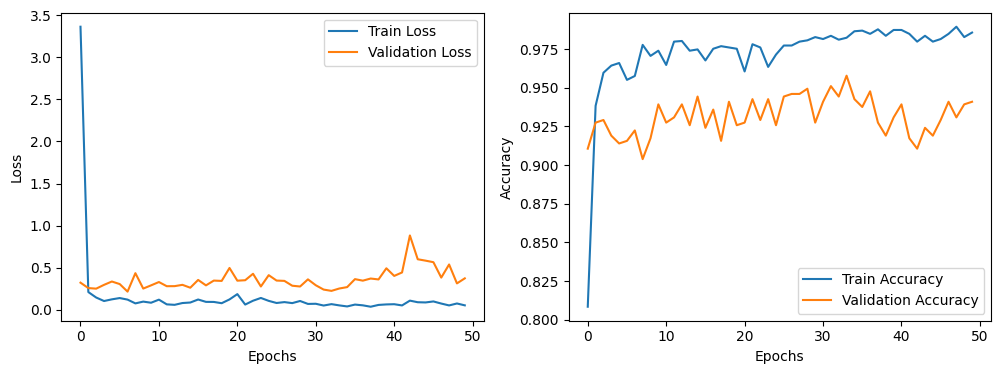

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_na.history['loss'], label='Train Loss')
plt.plot(history_na.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_na.history['accuracy'], label='Train Accuracy')
plt.plot(history_na.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 45s 653ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       296
           1       0.98      0.98      0.98       297
           2       1.00      1.00      1.00       308
           3       0.99      0.97      0.98       276
           4       0.99      1.00      0.99       290

    accuracy                           0.99      1467
   macro avg       0.99      0.99      0.99      1467
weighted avg       0.99      0.99      0.99      1467

Accuracy: 0.9856850715746421


# SqueezeNet

In [ ]:
!pip install torch torchvision

In [ ]:
# Install keras-squeezenet if not installed
!pip install keras-squeezenet

  Preparing metadata (setup.py) ... done
  Created wheel for keras-squeezenet: filename=keras_squeezenet-0.4-py3-none-any.whl size=3572 sha256=3a255333b46a7f13021186cc0a5839dbfc114b9d4579d7ad46b37a13a540e747
  Stored in directory: /root/.cache/pip/wheels/c5/8b/bb/eff0cb7dd0853f712e4ace15fbc569abd6141321ded205abdf
Successfully built keras-squeezenet


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Activation, concatenate, Dropout, GlobalAveragePooling2D, Flatten, Dense

# Define Fire Module
def fire_module(x, squeeze, expand):
    squeeze_layer = Conv2D(squeeze, (1, 1), activation='relu', padding='same')(x)
    expand_1x1 = Conv2D(expand, (1, 1), activation='relu', padding='same')(squeeze_layer)
    expand_3x3 = Conv2D(expand, (3, 3), activation='relu', padding='same')(squeeze_layer)
    return concatenate([expand_1x1, expand_3x3])

# Define SqueezeNet Model
def SqueezeNet(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = fire_module(x, 16, 64)
    x = fire_module(x, 16, 64)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = fire_module(x, 32, 128)
    x = fire_module(x, 32, 128)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = fire_module(x, 48, 192)
    x = fire_module(x, 48, 192)
    x = fire_module(x, 64, 256)
    x = fire_module(x, 64, 256)

    x = Dropout(0.5)(x)
    x = Conv2D(num_classes, (1, 1), activation='relu', padding='same')(x)
    x = GlobalAveragePooling2D()(x)
    outputs = Activation('softmax')(x)

    model = Model(inputs, outputs)
    return model

# Define model
model = SqueezeNet(input_shape=(224, 224, 3), num_classes=5)

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Print model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 224, 224, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 112, 112, 64)   │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 112, 112, 16)   │          1,040 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 112, 112, 64)   │          1,088 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 112, 112, 64)   │          9,280 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 112, 112, 128)  │              0 │ conv2d_2[0][0],        │
│                           │                        │                │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 112, 112, 16)   │          2,064 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 112, 112, 64)   │          1,088 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 112, 112, 64)   │          9,280 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 112, 112, 128)  │              0 │ conv2d_5[0][0],        │
│ (Concatenate)             │                        │                │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 56, 56, 128)    │              0 │ concatenate_1[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 56, 56, 32)     │          4,128 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 56, 56, 128)    │          4,224 │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 56, 56, 128)    │         36,992 │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 56, 56, 256)    │              0 │ conv2d_8[0][0],        │
│ (Concatenate)             │                        │                │ conv2d_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 56, 56, 32)     │          8,224 │ concatenate_2[0][0]    │
├──────────────────────

 Total params: 725,061 (2.77 MB)

 Trainable params: 725,061 (2.77 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Train the model
history_m1_a = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 38s 245ms/step - accuracy: 0.2160 - loss: 1.6098 - val_accuracy: 0.2129 - val_loss: 1.6092
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 147ms/step - accuracy: 0.2017 - loss: 1.6095 - val_accuracy: 0.2129 - val_loss: 1.6090
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.2233 - loss: 1.6085 - val_accuracy: 0.2129 - val_loss: 1.6089
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.2165 - loss: 1.6088 - val_accuracy: 0.2129 - val_loss: 1.6090
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.2062 - loss: 1.6094 - val_accuracy: 0.2129 - val_loss: 1.6089
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.2281 - loss: 1.6080 - val_accuracy: 0.2129 - val_loss: 1.6089
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - accuracy: 0.2132 - loss: 1.6090 - val_accuracy: 0.2129 - val_loss: 1.6089
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 147ms/step - accuracy: 0.2152 - loss: 1.6088 - val_accurac

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = model.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 249ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       120
           1       0.00      0.00      0.00       120
           2       0.21      1.00      0.35       128
           3       0.00      0.00      0.00       113
           4       0.00      0.00      0.00       120

    accuracy                           0.21       601
   macro avg       0.04      0.20      0.07       601
weighted avg       0.05      0.21      0.07       601

Accuracy: 0.2129783693843594


# MobileNetV3

In [10]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, BatchNormalization, ReLU, GlobalAveragePooling2D,
    Dense, Dropout, Add
)

# Define the Squeeze-and-Excitation block
def squeeze_and_excite_block(inputs, reduction_ratio=4):
    filters = inputs.shape[-1]
    reduced_filters = filters // reduction_ratio

    x = GlobalAveragePooling2D()(inputs)
    x = Dense(reduced_filters, activation='relu')(x)
    x = Dense(filters, activation='sigmoid')(x)

    return tf.keras.layers.multiply([inputs, x])

# Bottleneck Block with Integer Casting
def bottleneck_block(inputs, expansion, out_channels, kernel_size, stride, use_se):
    in_channels = inputs.shape[-1]

    # Step 1: Expansion
    x = Conv2D(int(in_channels * expansion), (1, 1), strides=1, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Step 2: Depthwise Convolution
    x = DepthwiseConv2D(kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Step 3: Squeeze-and-Excitation (optional)
    if use_se:
        x = squeeze_and_excite_block(x)

    # Step 4: Pointwise Projection
    x = Conv2D(out_channels, (1, 1), strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    # Add residual connection if input and output shapes match
    if stride == 1 and in_channels == out_channels:
        x = Add()([inputs, x])

    return x


# Define MobileNetV3Large Architecture
def MobileNetV3Large(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # Initial Convolution
    x = Conv2D(16, (3, 3), strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Bottleneck Blocks
    x = bottleneck_block(x, expansion=1, out_channels=16, kernel_size=(3, 3), stride=1, use_se=False)
    x = bottleneck_block(x, expansion=4, out_channels=24, kernel_size=(3, 3), stride=2, use_se=False)
    x = bottleneck_block(x, expansion=3, out_channels=24, kernel_size=(3, 3), stride=1, use_se=False)
    x = bottleneck_block(x, expansion=3, out_channels=40, kernel_size=(5, 5), stride=2, use_se=True)
    x = bottleneck_block(x, expansion=3, out_channels=40, kernel_size=(5, 5), stride=1, use_se=True)
    x = bottleneck_block(x, expansion=6, out_channels=80, kernel_size=(3, 3), stride=2, use_se=False)
    x = bottleneck_block(x, expansion=2.5, out_channels=80, kernel_size=(3, 3), stride=1, use_se=False)
    x = bottleneck_block(x, expansion=2.3, out_channels=80, kernel_size=(3, 3), stride=1, use_se=False)
    x = bottleneck_block(x, expansion=6, out_channels=112, kernel_size=(3, 3), stride=1, use_se=True)
    x = bottleneck_block(x, expansion=6, out_channels=112, kernel_size=(3, 3), stride=1, use_se=True)
    x = bottleneck_block(x, expansion=6, out_channels=160, kernel_size=(5, 5), stride=2, use_se=True)
    x = bottleneck_block(x, expansion=6, out_channels=160, kernel_size=(5, 5), stride=1, use_se=True)
    x = bottleneck_block(x, expansion=6, out_channels=160, kernel_size=(5, 5), stride=1, use_se=True)

    # Head of the network
    x = Conv2D(960, (1, 1), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

# Instantiate the model
input_shape = (224, 224, 3)
num_classes = 5
model = MobileNetV3Large(input_shape, num_classes)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Print model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 112, 112, 16)   │            448 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 112, 112, 16)   │             64 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu (ReLU)              │ (None, 112, 112, 16)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 112, 112, 16)   │            272 │ re_lu[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 112, 112, 16)   │             64 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_1 (ReLU)            │ (None, 112, 112, 16)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d          │ (None, 112, 112, 16)   │            160 │ re_lu_1[0][0]          │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 112, 112, 16)   │             64 │ depthwise_conv2d[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_2 (ReLU)            │ (None, 112, 112, 16)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 112, 112, 16)   │            272 │ re_lu_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 112, 112, 16)   │             64 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 112, 112, 16)   │              0 │ re_lu[0][0],           │
│                           │                        │                │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 112, 112, 64)   │          1,088 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 112, 112, 64)   │            256 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_3 (ReLU)            │ (None, 112, 112, 64)   │              0 │ batch_normalization_4… │
├──────────────────────

 Total params: 2,957,173 (11.28 MB)

 Trainable params: 2,934,197 (11.19 MB)

 Non-trainable params: 22,976 (89.75 KB)

In [11]:

# Train the model
history_suff = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 122s 780ms/step - accuracy: 0.5023 - loss: 1.2109 - val_accuracy: 0.1858 - val_loss: 1.7498
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 479ms/step - accuracy: 0.7788 - loss: 0.6095 - val_accuracy: 0.1858 - val_loss: 2.1230
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 42s 493ms/step - accuracy: 0.8584 - loss: 0.3899 - val_accuracy: 0.1858 - val_loss: 2.1531
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 486ms/step - accuracy: 0.8749 - loss: 0.3438 - val_accuracy: 0.1858 - val_loss: 2.1254
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 465ms/step - accuracy: 0.8964 - loss: 0.2631 - val_accuracy: 0.1858 - val_loss: 2.1619
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 476ms/step - accuracy: 0.8951 - loss: 0.2902 - val_accuracy: 0.1858 - val_loss: 2.2067
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 472ms/step - accuracy: 0.9167 - loss: 0.2474 - val_accuracy: 0.1858 - val_loss: 2.3722
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 484ms/step - accuracy: 0.8763 - loss: 0.3391 - val_acc

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = model.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 401ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.81      0.54       120
           1       1.00      0.13      0.24       120
           2       1.00      0.49      0.66       128
           3       0.66      0.98      0.79       113
           4       1.00      0.98      0.99       120

    accuracy                           0.67       601
   macro avg       0.81      0.68      0.64       601
weighted avg       0.82      0.67      0.64       601

Accuracy: 0.6738768718801996


# ShuffleNetV2

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, DepthwiseConv2D, BatchNormalization, ReLU, GlobalAveragePooling2D, Dense, Input, Add, Lambda, Concatenate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

def channel_shuffle(x, groups):
    height, width, in_channels = x.shape[1:]
    channels_per_group = in_channels // groups
    x = tf.reshape(x, [-1, height, width, groups, channels_per_group])
    x = tf.transpose(x, [0, 1, 2, 4, 3])
    x = tf.reshape(x, [-1, height, width, in_channels])
    return x

def shuffle_unit(inputs, out_channels, stride):
    half_channels = out_channels // 2

    if stride == 1:
        # Split input into two equal channels
        x1, x2 = Lambda(lambda z: tf.split(z, num_or_size_splits=2, axis=-1))(inputs)
    else:
        # When stride=2, downsample x1 with depthwise convolution
        x1 = DepthwiseConv2D(3, strides=2, padding='same', use_bias=False)(inputs)
        x1 = BatchNormalization()(x1)
        x1 = Conv2D(half_channels, 1, padding='same', use_bias=False)(x1)
        x1 = BatchNormalization()(x1)
        x1 = ReLU()(x1)

        x2 = Conv2D(half_channels, 1, padding='same', use_bias=False)(inputs)
        x2 = BatchNormalization()(x2)
        x2 = ReLU()(x2)

    # Apply depthwise convolution to x2
    x2 = DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x2)
    x2 = BatchNormalization()(x2)
    x2 = Conv2D(half_channels, 1, padding='same', use_bias=False)(x2)
    x2 = BatchNormalization()(x2)
    x2 = ReLU()(x2)

    # Concatenate x1 and x2, then shuffle channels
    x = Concatenate()([x1, x2])
    x = Lambda(lambda z: channel_shuffle(z, 2))(x)
    return x


def ShuffleNetV2(input_shape=(224, 224, 3), num_classes=5):
    inputs = Input(shape=input_shape)
    x = Conv2D(24, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = shuffle_unit(x, 116, stride=2)
    x = shuffle_unit(x, 116, stride=1)
    x = shuffle_unit(x, 232, stride=2)
    x = shuffle_unit(x, 232, stride=1)
    x = shuffle_unit(x, 464, stride=2)
    x = shuffle_unit(x, 464, stride=1)

    x = GlobalAveragePooling2D()(x)
    x = Dense(5, activation='softmax')(x)

    models = Model(inputs, x)
    return model

models = ShuffleNetV2()
models.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

models.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_29 (Conv2D)        │ (None, 112, 112, 24)   │            648 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_48    │ (None, 112, 112, 24)   │             96 │ conv2d_29[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_29 (ReLU)           │ (None, 112, 112, 24)   │              0 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_31 (Conv2D)        │ (None, 112, 112, 58)   │          1,392 │ re_lu_29[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_51    │ (None, 112, 112, 58)   │            232 │ conv2d_31[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_31 (ReLU)           │ (None, 112, 112, 58)   │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_19       │ (None, 56, 56, 24)     │            216 │ re_lu_29[0][0]         │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_20       │ (None, 56, 56, 58)     │            522 │ re_lu_31[0][0]         │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_49    │ (None, 56, 56, 24)     │             96 │ depthwise_conv2d_19[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_52    │ (None, 56, 56, 58)     │            232 │ depthwise_conv2d_20[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_30 (Conv2D)        │ (None, 56, 56, 58)     │          1,392 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_32 (Conv2D)        │ (None, 56, 56, 58)     │          3,364 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_50    │ (None, 56, 56, 58)     │            232 │ conv2d_30[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_53    │ (None, 56, 56, 58)     │            232 │ conv2d_32[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 303,589 (1.16 MB)

 Trainable params: 297,925 (1.14 MB)

 Non-trainable params: 5,664 (22.12 KB)

In [ ]:

# Train the model
history_suff = models.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 34s 154ms/step - accuracy: 0.7242 - loss: 0.7659 - val_accuracy: 0.2004 - val_loss: 1.6150
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - accuracy: 0.8978 - loss: 0.2786 - val_accuracy: 0.1858 - val_loss: 1.6421
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.9466 - loss: 0.1695 - val_accuracy: 0.1858 - val_loss: 1.6998
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.9457 - loss: 0.1570 - val_accuracy: 0.1858 - val_loss: 1.8531
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.9655 - loss: 0.1044 - val_accuracy: 0.1858 - val_loss: 2.0416
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.9659 - loss: 0.1057 - val_accuracy: 0.1858 - val_loss: 3.3874
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.9786 - loss: 0.0882 - val_accuracy: 0.2630 - val_loss: 2.4245
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9855 - loss: 0.0534 - val_accuracy: 0.2

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = models.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       120
           1       0.94      0.98      0.96       120
           2       0.97      1.00      0.98       128
           3       0.90      0.88      0.89       113
           4       0.96      0.97      0.96       120

    accuracy                           0.94       601
   macro avg       0.94      0.94      0.94       601
weighted avg       0.94      0.94      0.94       601

Accuracy: 0.940099833610649
